In [1]:
import model2_pipeline as m2

In [2]:
df = m2.load_data("cmu_real.csv", "chatgpt_cmu_synthetic_dataset.csv")

Combined shape: (40800, 35)

Class counts:
label
1    20400
0    20400
Name: count, dtype: int64


In [3]:
X, y = m2.preprocess_data(df)


Dropping columns: ['subject', 'sessionIndex', 'rep']

Feature shape: (40800, 31)
Label shape: (40800,)


In [4]:
X_train, X_test, y_train, y_test = m2.split_data(X, y)


Train shape: (32640, 31)
Test shape: (8160, 31)


In [5]:
X_train_mi, X_test_mi, mi_features, mi_scores = m2.select_mutual_info(
    X_train, y_train, X_test, k=10
)
X_train_mi_scaled, X_test_mi_scaled = m2.scale_data(X_train_mi, X_test_mi)
mi_results = m2.evaluate_models(X_train_mi_scaled, X_test_mi_scaled, y_train, y_test)


Top Mutual Information Features:
      Feature     Score
12     H.five  0.555610
30   H.Return  0.530883
0    H.period  0.521859
3         H.t  0.516794
18        H.o  0.513431
6         H.i  0.509816
27        H.l  0.497611
9         H.e  0.495141
24        H.n  0.486207
15  H.Shift.r  0.472041

Model: Logistic Regression
Accuracy: 0.5131127450980392

Confusion Matrix:
[[1970 2130]
 [1843 2217]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.48      0.50      4100
           1       0.51      0.55      0.53      4060

    accuracy                           0.51      8160
   macro avg       0.51      0.51      0.51      8160
weighted avg       0.51      0.51      0.51      8160

ROC-AUC: 0.5079098882614441

Model: Linear SVM
Accuracy: 0.5131127450980392

Confusion Matrix:
[[1970 2130]
 [1843 2217]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.48      0.50    

In [6]:
X_train_anova, X_test_anova, anova_features, anova_scores = m2.select_anova(
    X_train, y_train, X_test, k=10
)
X_train_anova_scaled, X_test_anova_scaled = m2.scale_data(X_train_anova, X_test_anova)
anova_results = m2.evaluate_models(X_train_anova_scaled, X_test_anova_scaled, y_train, y_test)


Top ANOVA Features:
            Feature       Score       P_Value
14  UD.five.Shift.r  123.160314  1.447013e-28
11        UD.e.five   87.567793  8.647288e-21
29      UD.l.Return   75.741032  3.383117e-18
17     UD.Shift.r.o   54.525444  1.571087e-13
26           UD.n.l   52.724018  3.924344e-13
2       UD.period.t   49.459186  2.065239e-12
5            UD.t.i   29.459637  5.749959e-08
20           UD.o.a   28.685903  8.569616e-08
23           UD.a.n   14.202308  1.644578e-04
8            UD.i.e   10.463965  1.218469e-03

Model: Logistic Regression
Accuracy: 0.46801470588235294

Confusion Matrix:
[[1635 2465]
 [1876 2184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.40      0.43      4100
           1       0.47      0.54      0.50      4060

    accuracy                           0.47      8160
   macro avg       0.47      0.47      0.47      8160
weighted avg       0.47      0.47      0.47      8160

ROC-AUC: 0.5116471

In [7]:
X_train_corr, X_test_corr, corr_features, corr_scores = m2.select_correlation(
    X_train, y_train, X_test, k=10
)
X_train_corr_scaled, X_test_corr_scaled = m2.scale_data(X_train_corr, X_test_corr)
corr_results = m2.evaluate_models(X_train_corr_scaled, X_test_corr_scaled, y_train, y_test)


Top Correlation Features:
           Feature     Score
0  UD.five.Shift.r  0.061313
1        UD.e.five  0.051728
2      UD.l.Return  0.048117
3     UD.Shift.r.o  0.040839
4           UD.n.l  0.040160
5      UD.period.t  0.038899
6           UD.t.i  0.030030
7           UD.o.a  0.029633
8           UD.a.n  0.020856
9           UD.i.e  0.017903

Model: Logistic Regression
Accuracy: 0.46801470588235294

Confusion Matrix:
[[1635 2465]
 [1876 2184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.40      0.43      4100
           1       0.47      0.54      0.50      4060

    accuracy                           0.47      8160
   macro avg       0.47      0.47      0.47      8160
weighted avg       0.47      0.47      0.47      8160

ROC-AUC: 0.5116471224318155

Model: Linear SVM
Accuracy: 0.4685049019607843

Confusion Matrix:
[[1631 2469]
 [1868 2192]]

Classification Report:
              precision    recall  f1-score   support

In [8]:
X_train_var, X_test_var, var_features, var_scores = m2.select_variance(
    X_train, X_test, threshold=0.0, k=10
)
X_train_var_scaled, X_test_var_scaled = m2.scale_data(X_train_var, X_test_var)
var_results = m2.evaluate_models(X_train_var_scaled, X_test_var_scaled, y_train, y_test)


Top Variance Features:
           Feature     Score
0  UD.five.Shift.r  0.080480
1        UD.e.five  0.079268
2        DD.e.five  0.070864
3  DD.five.Shift.r  0.067489
4      UD.l.Return  0.057346
5           UD.i.e  0.057322
6           DD.i.e  0.056106
7      UD.period.t  0.051419
8      DD.l.Return  0.050122
9      DD.period.t  0.045601

Model: Logistic Regression
Accuracy: 0.5705882352941176

Confusion Matrix:
[[2880 1220]
 [2284 1776]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.70      0.62      4100
           1       0.59      0.44      0.50      4060

    accuracy                           0.57      8160
   macro avg       0.58      0.57      0.56      8160
weighted avg       0.58      0.57      0.56      8160

ROC-AUC: 0.5710049261083744

Model: Linear SVM
Accuracy: 0.575735294117647

Confusion Matrix:
[[3013 1087]
 [2375 1685]]

Classification Report:
              precision    recall  f1-score   support

   

In [9]:
X_train_md, X_test_md, md_features, md_scores = m2.select_mean_difference(
    X_train, y_train, X_test, k=10
)
X_train_md_scaled, X_test_md_scaled = m2.scale_data(X_train_md, X_test_md)
md_results = m2.evaluate_models(X_train_md_scaled, X_test_md_scaled, y_train, y_test)


Top Mean Difference Features:
           Feature     Score
0  UD.five.Shift.r  0.034787
1        UD.e.five  0.029127
2      UD.l.Return  0.023045
3      UD.period.t  0.017641
4     UD.Shift.r.o  0.015432
5           UD.n.l  0.013174
6           UD.i.e  0.008572
7           UD.t.i  0.007774
8           UD.o.a  0.006564
9           UD.a.n  0.004426

Model: Logistic Regression
Accuracy: 0.46801470588235294

Confusion Matrix:
[[1635 2465]
 [1876 2184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.40      0.43      4100
           1       0.47      0.54      0.50      4060

    accuracy                           0.47      8160
   macro avg       0.47      0.47      0.47      8160
weighted avg       0.47      0.47      0.47      8160

ROC-AUC: 0.5116471224318155

Model: Linear SVM
Accuracy: 0.4685049019607843

Confusion Matrix:
[[1631 2469]
 [1868 2192]]

Classification Report:
              precision    recall  f1-score   sup

In [10]:
X_train_rfe_lr, X_test_rfe_lr, rfe_lr_features = m2.select_rfe_lr(
    X_train, y_train, X_test, k=10
)
X_train_rfe_lr_scaled, X_test_rfe_lr_scaled = m2.scale_data(X_train_rfe_lr, X_test_rfe_lr)
rfe_lr_results = m2.evaluate_models(X_train_rfe_lr_scaled, X_test_rfe_lr_scaled, y_train, y_test)


RFE Logistic Regression Features:
['H.t', 'DD.t.i', 'UD.t.i', 'H.five', 'DD.five.Shift.r', 'UD.five.Shift.r', 'H.Shift.r', 'H.o', 'DD.o.a', 'UD.o.a']

Model: Logistic Regression
Accuracy: 0.5720588235294117

Confusion Matrix:
[[4100    0]
 [3492  568]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70      4100
           1       1.00      0.14      0.25      4060

    accuracy                           0.57      8160
   macro avg       0.77      0.57      0.47      8160
weighted avg       0.77      0.57      0.47      8160

ROC-AUC: 0.4966090952781449

Model: Linear SVM
Accuracy: 0.5731617647058823

Confusion Matrix:
[[4100    0]
 [3483  577]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70      4100
           1       1.00      0.14      0.25      4060

    accuracy                           0.57      8160
   macro avg       0.77      0.

In [11]:
X_train_rfe_svm, X_test_rfe_svm, rfe_svm_features = m2.select_rfe_svm(
    X_train, y_train, X_test, k=10
)
X_train_rfe_svm_scaled, X_test_rfe_svm_scaled = m2.scale_data(X_train_rfe_svm, X_test_rfe_svm)
rfe_svm_results = m2.evaluate_models(X_train_rfe_svm_scaled, X_test_rfe_svm_scaled, y_train, y_test)


RFE Linear SVM Features:
['H.t', 'DD.t.i', 'UD.t.i', 'H.five', 'DD.five.Shift.r', 'UD.five.Shift.r', 'H.o', 'DD.o.a', 'UD.o.a', 'H.a']

Model: Logistic Regression
Accuracy: 0.5730392156862745

Confusion Matrix:
[[4079   21]
 [3463  597]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.99      0.70      4100
           1       0.97      0.15      0.26      4060

    accuracy                           0.57      8160
   macro avg       0.75      0.57      0.48      8160
weighted avg       0.75      0.57      0.48      8160

ROC-AUC: 0.5048946293403821

Model: Linear SVM
Accuracy: 0.5758578431372549

Confusion Matrix:
[[4075   25]
 [3436  624]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.99      0.70      4100
           1       0.96      0.15      0.27      4060

    accuracy                           0.58      8160
   macro avg       0.75      0.57      0.48   

In [12]:
X_train_rfe_rf, X_test_rfe_rf, rfe_rf_features = m2.select_rfe_rf(
    X_train, y_train, X_test, k=10
)
X_train_rfe_rf_scaled, X_test_rfe_rf_scaled = m2.scale_data(X_train_rfe_rf, X_test_rfe_rf)
rfe_rf_results = m2.evaluate_models(X_train_rfe_rf_scaled, X_test_rfe_rf_scaled, y_train, y_test)


RFE Random Forest Features:
['UD.period.t', 'DD.t.i', 'UD.t.i', 'DD.i.e', 'UD.i.e', 'UD.e.five', 'UD.five.Shift.r', 'UD.Shift.r.o', 'UD.o.a', 'UD.l.Return']

Model: Logistic Regression
Accuracy: 0.5125

Confusion Matrix:
[[2084 2016]
 [1962 2098]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.51      0.51      4100
           1       0.51      0.52      0.51      4060

    accuracy                           0.51      8160
   macro avg       0.51      0.51      0.51      8160
weighted avg       0.51      0.51      0.51      8160

ROC-AUC: 0.5343304097080379

Model: Linear SVM
Accuracy: 0.5116421568627451

Confusion Matrix:
[[2078 2022]
 [1963 2097]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.51      0.51      4100
           1       0.51      0.52      0.51      4060

    accuracy                           0.51      8160
   macro avg       0.51      0.51   

In [13]:
X_train_sfm_lr, X_test_sfm_lr, sfm_lr_features, sfm_lr_scores = m2.select_sfm_lr(
    X_train, y_train, X_test, k=10
)
X_train_sfm_lr_scaled, X_test_sfm_lr_scaled = m2.scale_data(X_train_sfm_lr, X_test_sfm_lr)
sfm_lr_results = m2.evaluate_models(X_train_sfm_lr_scaled, X_test_sfm_lr_scaled, y_train, y_test)


SelectFromModel Logistic Regression Features:
            Feature     Score
5            UD.t.i  5.628165
4            DD.t.i  5.493530
18              H.o  5.452087
20           UD.o.a  5.421051
12           H.five  5.415321
19           DD.o.a  5.335961
13  DD.five.Shift.r  5.138270
14  UD.five.Shift.r  5.133251
3               H.t  5.089289
17     UD.Shift.r.o  4.221696

Model: Logistic Regression
Accuracy: 0.6072303921568627

Confusion Matrix:
[[3618  482]
 [2723 1337]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.88      0.69      4100
           1       0.74      0.33      0.45      4060

    accuracy                           0.61      8160
   macro avg       0.65      0.61      0.57      8160
weighted avg       0.65      0.61      0.57      8160

ROC-AUC: 0.5175022227562177

Model: Linear SVM
Accuracy: 0.6064950980392156

Confusion Matrix:
[[3603  497]
 [2714 1346]]

Classification Report:
              precision

In [14]:
X_train_sfm_rf, X_test_sfm_rf, sfm_rf_features, sfm_rf_scores = m2.select_sfm_rf(
    X_train, y_train, X_test, k=10
)
X_train_sfm_rf_scaled, X_test_sfm_rf_scaled = m2.scale_data(X_train_sfm_rf, X_test_sfm_rf)
sfm_rf_results = m2.evaluate_models(X_train_sfm_rf_scaled, X_test_sfm_rf_scaled, y_train, y_test)


SelectFromModel Random Forest Features:
            Feature     Score
7            DD.i.e  0.124856
8            UD.i.e  0.109448
14  UD.five.Shift.r  0.066136
2       UD.period.t  0.059672
5            UD.t.i  0.059460
29      UD.l.Return  0.051637
17     UD.Shift.r.o  0.050230
4            DD.t.i  0.040102
1       DD.period.t  0.037733
19           DD.o.a  0.036345

Model: Logistic Regression
Accuracy: 0.5432598039215686

Confusion Matrix:
[[2392 1708]
 [2019 2041]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.58      0.56      4100
           1       0.54      0.50      0.52      4060

    accuracy                           0.54      8160
   macro avg       0.54      0.54      0.54      8160
weighted avg       0.54      0.54      0.54      8160

ROC-AUC: 0.5464202210741318

Model: Linear SVM
Accuracy: 0.539828431372549

Confusion Matrix:
[[2382 1718]
 [2037 2023]]

Classification Report:
              precision    rec

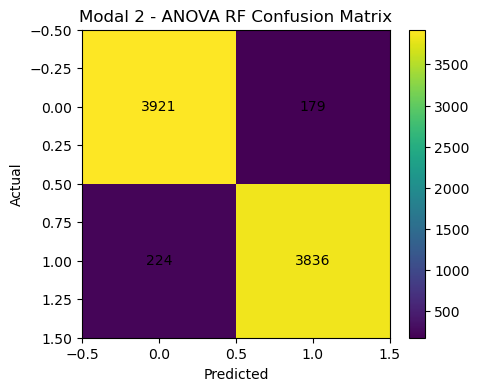

In [15]:
best_model = anova_results.iloc[0]["Model_Object"]
best_cm = anova_results.iloc[0]["Confusion_Matrix"]

m2.plot_confusion_matrix(best_cm, title="Modal 2 - ANOVA RF Confusion Matrix")

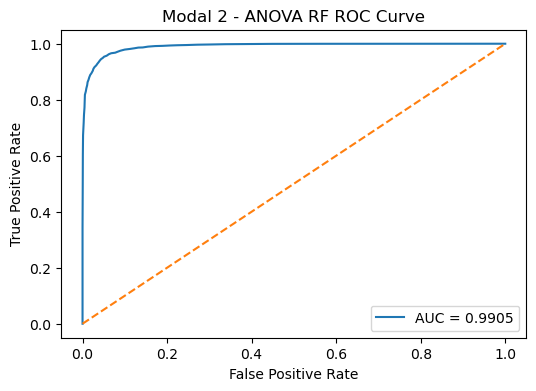

In [16]:
m2.plot_roc(best_model, X_test_anova_scaled, y_test, title="Modal 2 - ANOVA RF ROC Curve")


Feature: UD.five.Shift.r
Real Mean: 0.3619829019607843
Synthetic Mean: 0.3277822807912203
Real Std: 0.26088585522438773
Synthetic Std: 0.3057090027694045


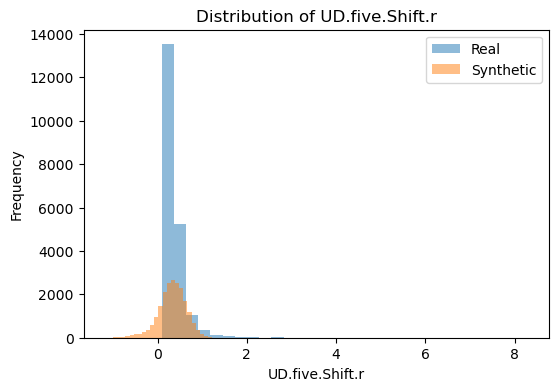

In [17]:
m2.plot_feature_distribution(df, anova_features[0])

In [18]:
m2.validate_best_model(best_model, X_train_anova_scaled, y_train)


3-Fold CV Scores: [0.94908088 0.94669118 0.9515625 ]
CV Mean: 0.9491115196078431


array([0.94908088, 0.94669118, 0.9515625 ])

In [19]:
feature_summary = m2.feature_selection_summary(
    mi_features,
    anova_features,
    corr_features,
    var_features,
    md_features,
    rfe_lr_features,
    rfe_svm_features,
    rfe_rf_features,
    sfm_lr_features,
    sfm_rf_features
)


Feature Selection Summary:
            Feature  Times_Selected
10  UD.five.Shift.r               9
16           UD.t.i               8
17           UD.o.a               7
19           UD.i.e               6
12      UD.l.Return               6
13     UD.Shift.r.o               6
15      UD.period.t               6
25           DD.t.i               5
11        UD.e.five               5
0            H.five               4
26           DD.o.a               4
3               H.t               4
4               H.o               4
21  DD.five.Shift.r               4
22           DD.i.e               3
18           UD.a.n               3
14           UD.n.l               3
9         H.Shift.r               2
24      DD.period.t               2
1          H.Return               1
8               H.n               1
20        DD.e.five               1
7               H.e               1
6               H.l               1
23      DD.l.Return               1
5               H.i               1
